## BAGIAN 0 & 1: Import Library dan Memuat Dataset
Tahap awal ini memuat pustaka (library) yang dibutuhkan untuk manipulasi data (Pandas, Numpy), visualisasi (Matplotlib, Seaborn), dan algoritma clustering (Scikit-Learn). Data transaksi historis kemudian diimpor untuk dilakukan Exploratory Data Analysis (EDA) awal.

In [ ]:
# ============================================================
# BAGIAN 0: INSTALASI DAN IMPORT LIBRARY
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors         
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist
from scipy.stats import skew

# Pengaturan tampilan plot
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

In [ ]:
# ============================================================
# BAGIAN 1: MEMUAT DATASET
# ============================================================
# Muat dataset dari file Excel
# Ganti nama file sesuai dengan nama file yang diupload
df = pd.read_excel('../OnlineRetail.xlsx')
print(df.head())
print(df.info())

# Tampilkan jumlah missing value per kolom
print("\n❓ Jumlah missing value per kolom:")
print(df.isnull().sum())

# Tampilkan statistik deskriptif
print("\n📈 Statistik deskriptif:")
print(df.describe())

print(f"Dataset berhasil dimuat: {df.shape[0]} baris, {df.shape[1]} kolom")

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       -----------

## BAGIAN 2: Data Preprocessing
Tahap pembersihan data sangat krusial. Baris dengan *missing values*, transaksi tanpa identitas pelanggan (`CustomerID`), serta transaksi bernilai negatif (Quantity atau UnitPrice <= 0) dihapus karena mengindikasikan retur barang yang dapat mengacaukan perhitungan nilai *Monetary*.

In [ ]:
# ============================================================
# BAGIAN 2: PREPROCESSING DATA
# ============================================================
# Salin dataframe agar data asli tidak berubah
df_clean = df.copy()

# Simpan jumlah data awal ke variabel
data_awal = len(df_clean)

# 2.1 Konversi kolom InvoiceDate ke format datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# 2.2 Hapus baris dengan missing value (secara umum)
before = len(df_clean)
df_clean = df_clean.dropna()
drop_na = len(df_clean) - before
print(f"Hapus missing value (NA): {abs(drop_na)} baris dihapus")

# 2.3 Hapus data khusus tanpa CustomerID (kosong atau bernilai 0)
before = len(df_clean)
df_clean = df_clean[df_clean['CustomerID'].notna()]
df_clean = df_clean[df_clean['CustomerID'] != 0]
drop_id = len(df_clean) - before
print(f"Hapus data tanpa CustomerID: {abs(drop_id)} baris dihapus")

# (Gabungkan kembali drop_na dan drop_id khusus untuk CSV agar Dashboard tidak error)
drop_missing = drop_na + drop_id

# 2.4 Hapus transaksi dengan Quantity <= 0
before = len(df_clean)
df_clean = df_clean[df_clean['Quantity'] > 0]
drop_qty = len(df_clean) - before
print(f"Hapus Quantity <= 0: {abs(drop_qty)} baris dihapus")

# 2.5 Hapus transaksi dengan UnitPrice <= 0
before = len(df_clean)
df_clean = df_clean[df_clean['UnitPrice'] > 0]
drop_price = len(df_clean) - before
print(f"Hapus UnitPrice <= 0: {abs(drop_price)} baris dihapus")

# Simpan jumlah data bersih ke variabel
data_bersih = len(df_clean)

# Konversi CustomerID ke integer
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

print(f"\nPreprocessing selesai: {data_bersih} baris data bersih")
print(f"(dari {data_awal} baris data awal)")
print(f"Date range: {df_clean['InvoiceDate'].min().date()} → {df_clean['InvoiceDate'].max().date()}")
print(f"Unique customers: {df_clean['CustomerID'].nunique():,}")
print(f"Unique invoices:  {df_clean['InvoiceNo'].nunique():,}")

# --- EKSPOR SUMMARY KE CSV UNTUK DASHBOARD ---
df_summary = pd.DataFrame({
    'Keterangan': ['Data Awal', 'Missing Value & No ID', 'Quantity <= 0', 'UnitPrice <= 0', 'Data Bersih'],
    'Nilai': [data_awal, drop_missing, drop_qty, drop_price, data_bersih]
})
df_summary.to_csv('preprocessing_summary.csv', index=False)

Hapus missing value (NA): 135080 baris dihapus
Hapus data tanpa CustomerID: 0 baris dihapus
Hapus Quantity <= 0: 8905 baris dihapus
Hapus UnitPrice <= 0: 40 baris dihapus

Preprocessing selesai: 397884 baris data bersih
(dari 541909 baris data awal)
Date range: 2010-12-01 → 2011-12-09
Unique customers: 4,338
Unique invoices:  18,532


## BAGIAN 3 & 4: Feature Engineering (RFM) & Distribusi
Membentuk variabel *Recency* (hari sejak belanja terakhir), *Frequency* (jumlah nota belanja unik), dan *Monetary* (total uang yang dihabiskan). Visualisasi histogram digunakan untuk mendeteksi *skewness* (kemiringan) pada data.

In [ ]:
# ============================================================
# BAGIAN 3: FEATURE ENGINEERING - PEMBENTUKAN VARIABEL RFM
# ============================================================
# Tentukan tanggal referensi (tanggal maksimum dalam dataset + 1 hari)
tanggal_referensi = df_clean['InvoiceDate'].max() + pd.DateOffset(days=1)
print(f"📅 Tanggal referensi: {tanggal_referensi.date()}")

# PERBAIKAN: Hitung TotalSum dulu sebelum groupby
df_clean['TotalSum'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Hitung nilai RFM per CustomerID
rfm = df_clean.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (tanggal_referensi - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalSum',    'sum')
).reset_index()

# Tampilkan hasil RFM
print("\n📋 Lima data RFM pertama:")
print(rfm.head())

print("\n📊 Statistik RFM:")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())

print(f"RFM berhasil dibentuk: {len(rfm)} pelanggan")

📅 Tanggal referensi: 2011-12-10

📋 Lima data RFM pertama:
   CustomerID  Recency  Frequency  Monetary
0       12346      326          1  77183.60
1       12347        2          7   4310.00
2       12348       75          4   1797.24
3       12349       19          1   1757.55
4       12350      310          1    334.40

📊 Statistik RFM:
           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2054.266460
std     100.014169     7.697998    8989.230441
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     307.415000
50%      51.000000     2.000000     674.485000
75%     142.000000     5.000000    1661.740000
max     374.000000   209.000000  280206.020000
RFM berhasil dibentuk: 4338 pelanggan


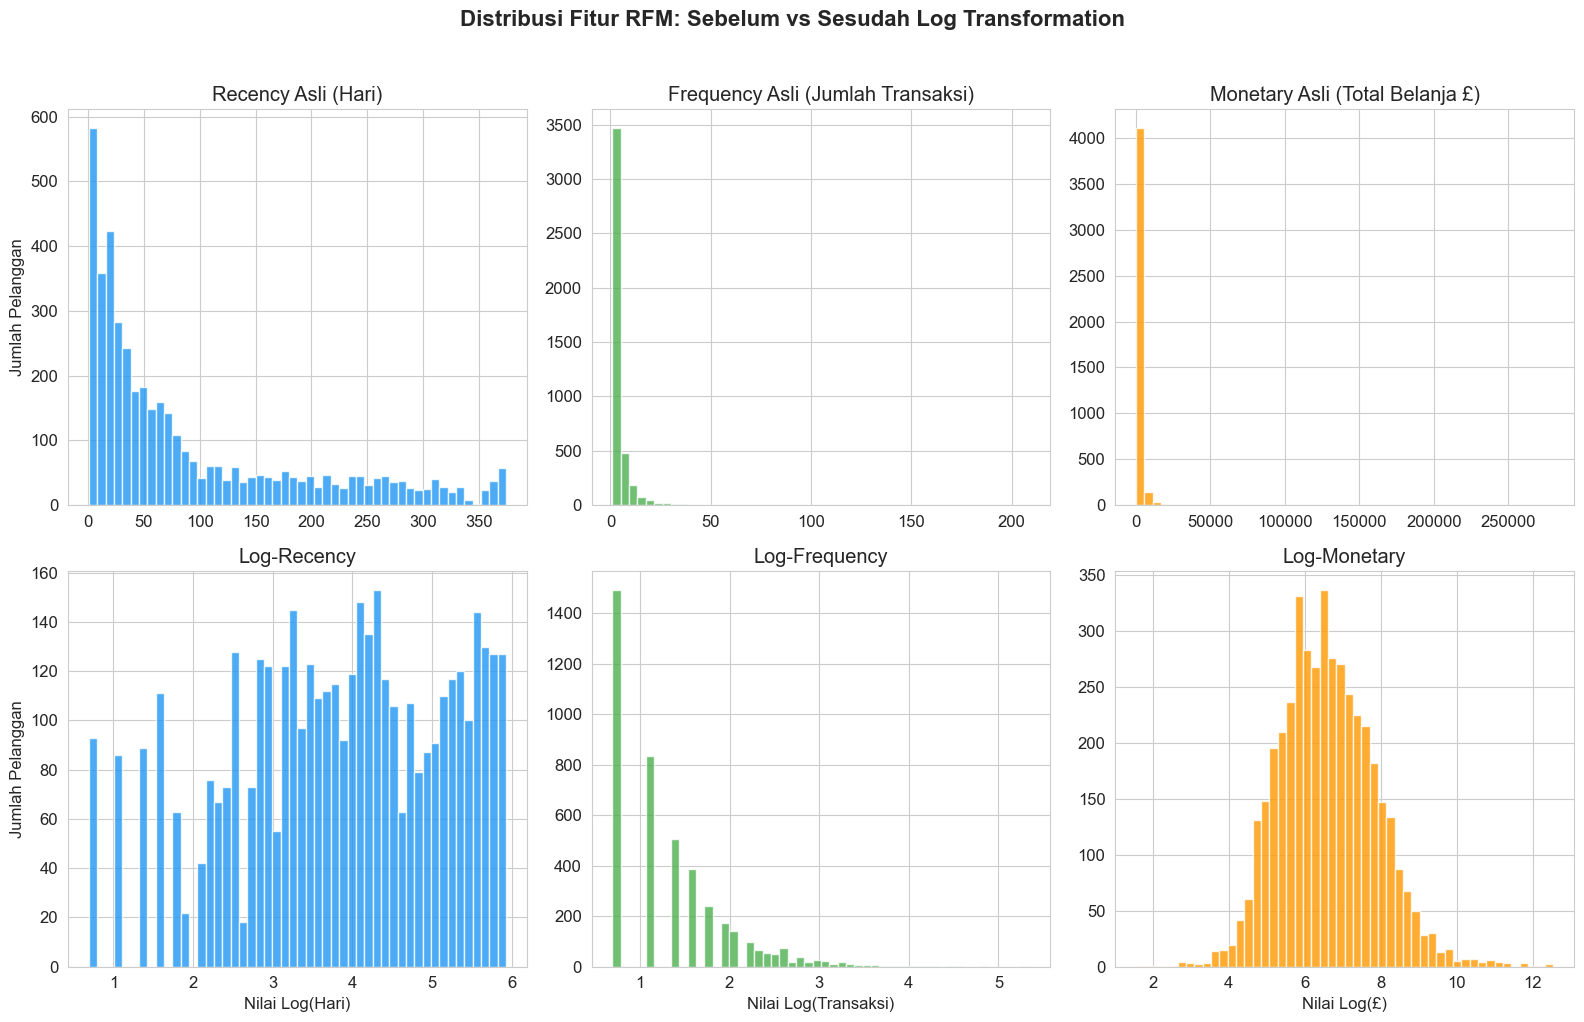

In [ ]:
# ============================================================
# BAGIAN 4: VISUALISASI DISTRIBUSI RFM (BEFORE VS AFTER LOG)
# ============================================================
# Membuat area gambar dengan 2 Baris dan 3 Kolom (Total 6 Grafik)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribusi Fitur RFM: Sebelum vs Sesudah Log Transformation', fontsize=16, fontweight='bold', y=1.02)

# --- BARIS 1: SEBELUM TRANSFORMASI (Data Asli) ---
axes[0, 0].hist(rfm['Recency'], bins=50, color='#2196F3', edgecolor='white', alpha=0.8)
axes[0, 0].set_title('Recency Asli (Hari)')
axes[0, 0].set_ylabel('Jumlah Pelanggan')

axes[0, 1].hist(rfm['Frequency'], bins=50, color='#4CAF50', edgecolor='white', alpha=0.8)
axes[0, 1].set_title('Frequency Asli (Jumlah Transaksi)')

axes[0, 2].hist(rfm['Monetary'], bins=50, color='#FF9800', edgecolor='white', alpha=0.8)
axes[0, 2].set_title('Monetary Asli (Total Belanja £)')

# --- BARIS 2: SESUDAH TRANSFORMASI LOGARITMA ---
# Kita gunakan np.log1p() langsung di dalam visualisasi untuk melihat perubahannya
axes[1, 0].hist(np.log1p(rfm['Recency']), bins=50, color='#2196F3', edgecolor='white', alpha=0.8)
axes[1, 0].set_title('Log-Recency')
axes[1, 0].set_xlabel('Nilai Log(Hari)')
axes[1, 0].set_ylabel('Jumlah Pelanggan')

axes[1, 1].hist(np.log1p(rfm['Frequency']), bins=50, color='#4CAF50', edgecolor='white', alpha=0.8)
axes[1, 1].set_title('Log-Frequency')
axes[1, 1].set_xlabel('Nilai Log(Transaksi)')

axes[1, 2].hist(np.log1p(rfm['Monetary']), bins=50, color='#FF9800', edgecolor='white', alpha=0.8)
axes[1, 2].set_title('Log-Monetary')
axes[1, 2].set_xlabel('Nilai Log(£)')

plt.tight_layout()
plt.savefig('distribusi_rfm_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

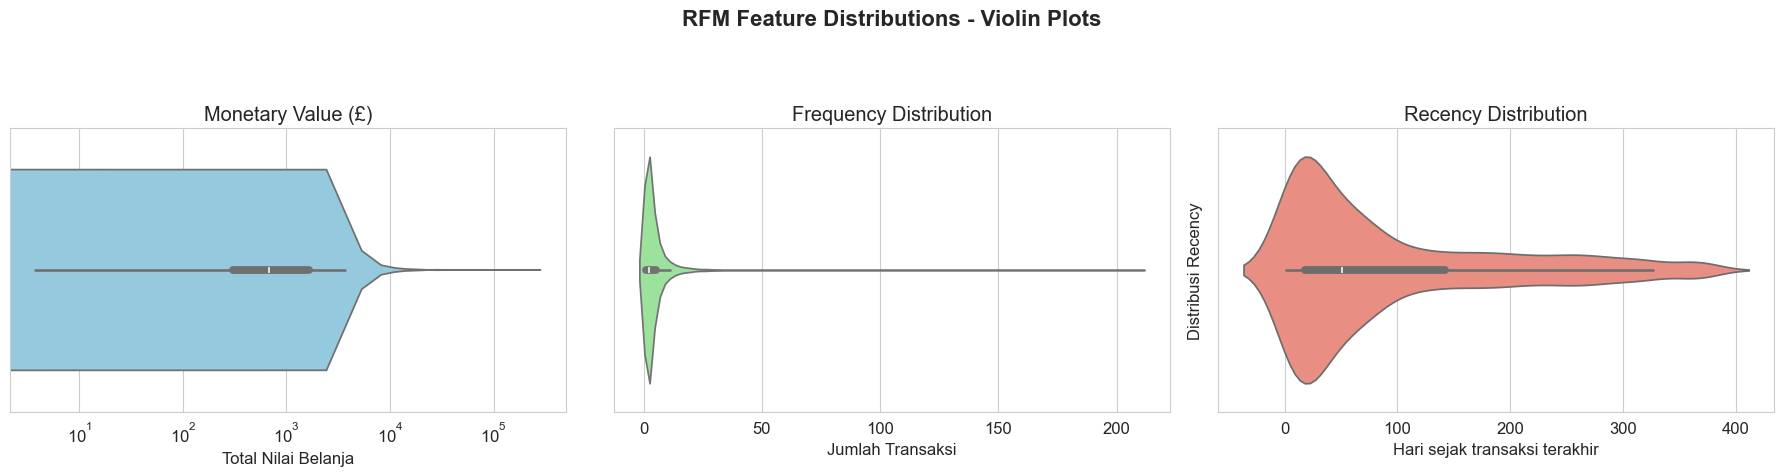

In [ ]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.violinplot(x=rfm['Monetary'], color='skyblue')
plt.title('Monetary Value (£)')
plt.xlabel('Total Nilai Belanja')
plt.xscale('log')  # Optional: log scale to manage skewness

plt.subplot(1, 3, 2)
sns.violinplot(x=rfm['Frequency'], color='lightgreen')
plt.title('Frequency Distribution')
plt.xlabel('Jumlah Transaksi')

plt.subplot(1, 3, 3)
sns.violinplot(x=rfm['Recency'], color='salmon')
plt.title('Recency Distribution')
plt.xlabel('Hari sejak transaksi terakhir')
plt.ylabel('Distribusi Recency')

plt.suptitle('RFM Feature Distributions - Violin Plots', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.90])
plt.show()

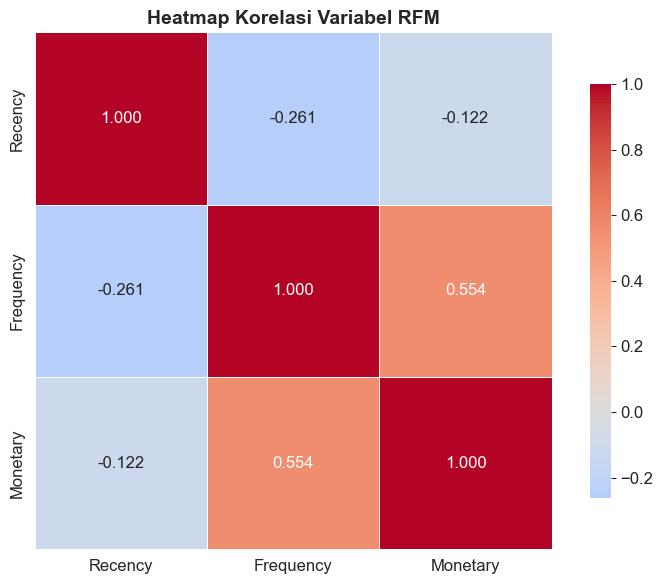

In [ ]:
# Heatmap korelasi antar variabel RFM
plt.figure(figsize=(8, 6))
korelasi = rfm[['Recency', 'Frequency', 'Monetary']].corr()
sns.heatmap(korelasi, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Heatmap Korelasi Variabel RFM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_korelasi_rfm.png', dpi=150, bbox_inches='tight')
plt.show()

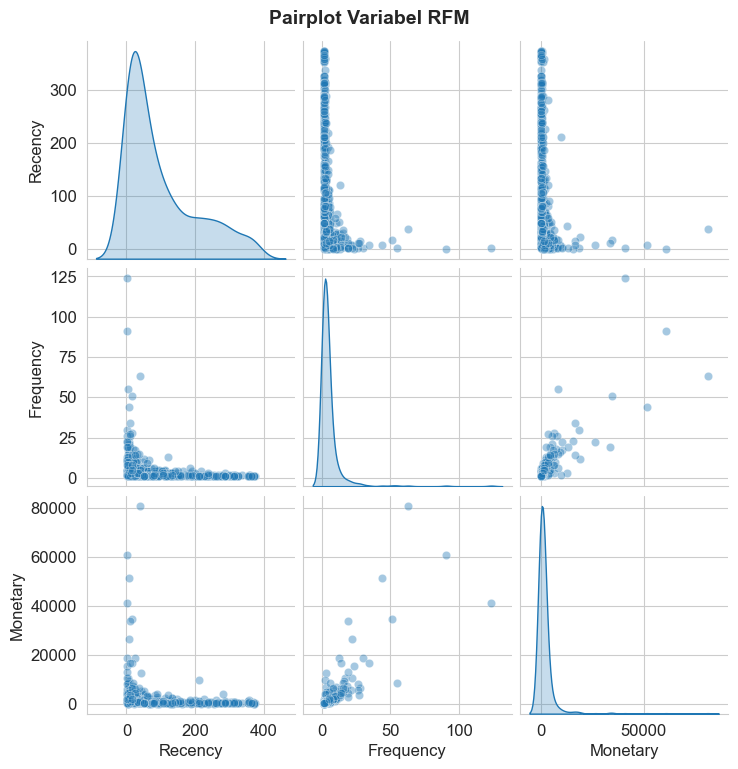

In [ ]:
# Pairplot distribusi RFM
rfm_sample = rfm[['Recency', 'Frequency', 'Monetary']].sample(
    min(500, len(rfm)), random_state=42
)
pairplot = sns.pairplot(rfm_sample, diag_kind='kde', plot_kws={'alpha': 0.4})
pairplot.fig.suptitle('Pairplot Variabel RFM', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('pairplot_rfm.png', dpi=150, bbox_inches='tight')
plt.show()

## BAGIAN 5: Normalisasi Data (Log Transformation & Z-Score)
Karena data transaksi (terutama Monetary) memiliki kemiringan positif yang ekstrim (*highly right-skewed*), data ditransformasi menggunakan logaritma (`np.log1p`) agar distribusinya lebih normal. Setelah itu, data distandarisasi menggunakan *Z-Score* agar algoritma berbasis jarak (K-Means & DBSCAN) tidak terdominasi oleh variabel dengan skala nominal besar.

In [ ]:
# ============================================================
# BAGIAN 5: NORMALISASI DATA (LOG TRANSFORMATION + Z-SCORE)
# ============================================================
# Ambil fitur RFM untuk normalisasi
fitur_rfm = rfm[['Recency', 'Frequency', 'Monetary']].copy()

# PERBAIKAN: 1. Lakukan Log Transformation
fitur_rfm_log = np.log1p(fitur_rfm) 

# PERBAIKAN: 2. Lakukan Z-Score hanya pada data yang sudah di-log
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(fitur_rfm_log)

# Ubah ke DataFrame untuk kemudahan
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled'],
    index=rfm['CustomerID'] # Gunakan index CustomerID agar terhubung
)

print("📊 Statistik setelah normalisasi:")
print(rfm_scaled_df.describe().round(4))
print("Normalisasi Z-score pada data Log berhasil dilakukan")
print("\nSkewness sebelum log-transform:")
print(fitur_rfm.apply(skew))
print("\nSkewness sesudah log-transform (sebelum Z-score):")
print(fitur_rfm_log.apply(skew))

📊 Statistik setelah normalisasi:
       Recency_scaled  Frequency_scaled  Monetary_scaled
count       4338.0000         4338.0000        4338.0000
mean          -0.0000           -0.0000           0.0000
std            1.0001            1.0001           1.0001
min           -2.3413           -0.9552          -4.0046
25%           -0.6614           -0.9552          -0.6857
50%            0.0899           -0.3616          -0.0622
75%            0.8448            0.6532           0.6542
max            1.5642            5.8585           4.7316
Normalisasi Z-score pada data Log berhasil dilakukan

Skewness sebelum log-transform:
Recency       1.245617
Frequency    12.062858
Monetary     19.318270
dtype: float64

Skewness sesudah log-transform (sebelum Z-score):
Recency     -0.379038
Frequency    1.208234
Monetary     0.393416
dtype: float64


## BAGIAN 6: K-Means Clustering
Implementasi K-Means membutuhkan penentuan jumlah cluster (*k*) di awal. Digunakan kombinasi *Elbow Method* (Inertia) dan *Silhouette Score* untuk mencari nilai *k* yang paling objektif dan optimal.

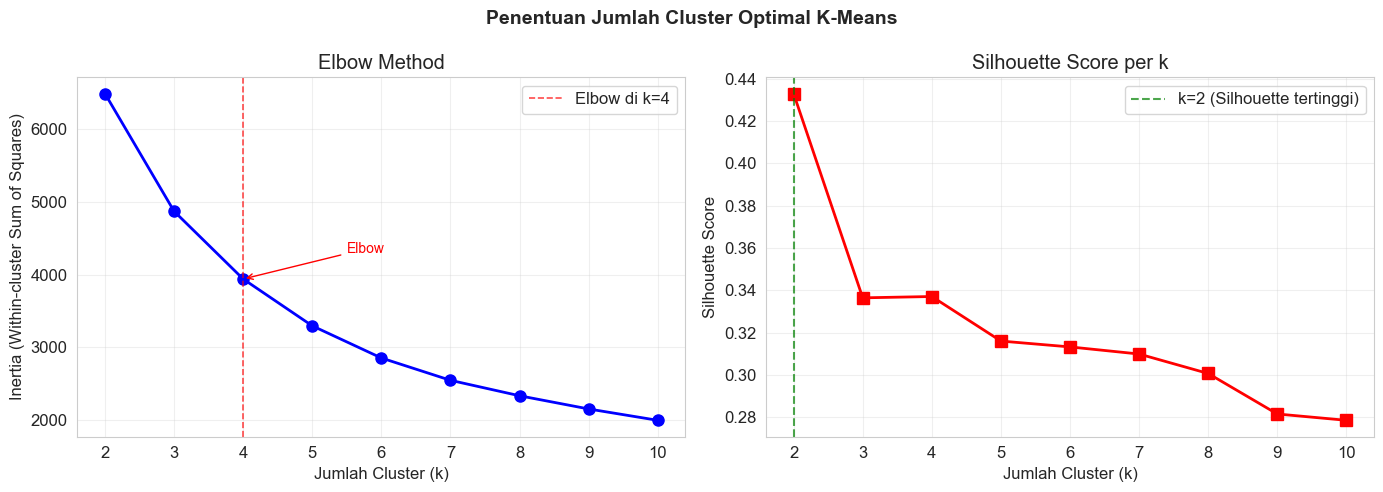

In [ ]:
# ============================================================
# BAGIAN 6: K-MEANS CLUSTERING
# ============================================================
# --- 6.1 Menentukan k optimal dengan Elbow Method ---
inertia_list    = []
silhouette_list = []
k_range         = range(2, 11)   # TETAP mulai dari 2, jangan dihilangkan

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(rfm_scaled)
    inertia_list.append(kmeans_temp.inertia_)
    sil_score = silhouette_score(rfm_scaled, kmeans_temp.labels_)
    silhouette_list.append(sil_score)

# Plot Elbow dan Silhouette berdampingan (SATU gambar gabungan)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Penentuan Jumlah Cluster Optimal K-Means', fontsize=14, fontweight='bold')

# Elbow Method
axes[0].plot(k_range, inertia_list, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Jumlah Cluster (k)')
axes[0].set_ylabel('Inertia (Within-cluster Sum of Squares)')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(list(k_range))
axes[0].grid(True, alpha=0.3)

# Tandai titik elbow di k=4 (index aman: k=4 ada di posisi ke-(4-2)=2 dalam list)
idx_k4 = list(k_range).index(4)
axes[0].axvline(x=4, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label='Elbow di k=4')
axes[0].annotate('Elbow', xy=(4, inertia_list[idx_k4]),
                  xytext=(5.5, inertia_list[idx_k4] + (max(inertia_list) - min(inertia_list)) * 0.08),
                  arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=10)
axes[0].legend()

# Silhouette Score
axes[1].plot(k_range, silhouette_list, 'rs-', linewidth=2, markersize=8)
axes[1].set_xlabel('Jumlah Cluster (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score per k')
axes[1].set_xticks(list(k_range))
axes[1].grid(True, alpha=0.3)

k_terbaik_sil = k_range[np.argmax(silhouette_list)]
axes[1].axvline(x=k_terbaik_sil, color='green', linestyle='--', alpha=0.7,
                label=f'k={k_terbaik_sil} (Silhouette tertinggi)')
axes[1].legend()

plt.tight_layout()
plt.savefig('kmeans_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# --- 6.2 JALANKAN K-MEANS FINAL DENGAN K = 4 ---
# tabel_k = pd.DataFrame({'k': list(k_range), 'Silhouette Score': silhouette_list})
# print(tabel_k.to_string(index=False))

# print(f"\n⚠️  Meskipun Silhouette tertinggi ada di k={k_terbaik_sil},")
# print("➡️  Penelitian ini menetapkan k=4 berdasarkan analisis Elbow dan Utilitas Bisnis.")

# KUNCI k_optimal di angka 4
k_optimal = 4

# Jalankan K-Means satu kali saja secara definitif
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
rfm['Cluster_KMeans'] = kmeans.fit_predict(rfm_scaled)

# Evaluasi K-Means
sil_kmeans = silhouette_score(rfm_scaled, rfm['Cluster_KMeans'])
dbi_kmeans = davies_bouldin_score(rfm_scaled, rfm['Cluster_KMeans'])

# print(f"   Nilai K K-Means = {k_optimal}")
# print(f"   Silhouette Score : {sil_kmeans:.4f}")
# print(f"   Davies-Bouldin Index: {dbi_kmeans:.4f}")
# Hitung Profil Rata-rata dari k=4
profil_k4 = rfm.groupby('Cluster_KMeans').agg(
    Jumlah_Pelanggan=('CustomerID','count'),
    Recency_Rata2=('Recency','mean'),
    Frequency_Rata2=('Frequency','mean'),
    Monetary_Rata2=('Monetary','mean')
).round(2)
print(profil_k4)

                Jumlah_Pelanggan  Recency_Rata2  Frequency_Rata2  \
Cluster_KMeans                                                     
0                            837          18.12             2.15   
1                            716          12.13            13.71   
2                           1173          71.08             4.08   
3                           1612         182.50             1.32   

                Monetary_Rata2  
Cluster_KMeans                  
0                       551.82  
1                      8074.27  
2                      1802.83  
3                       343.45  


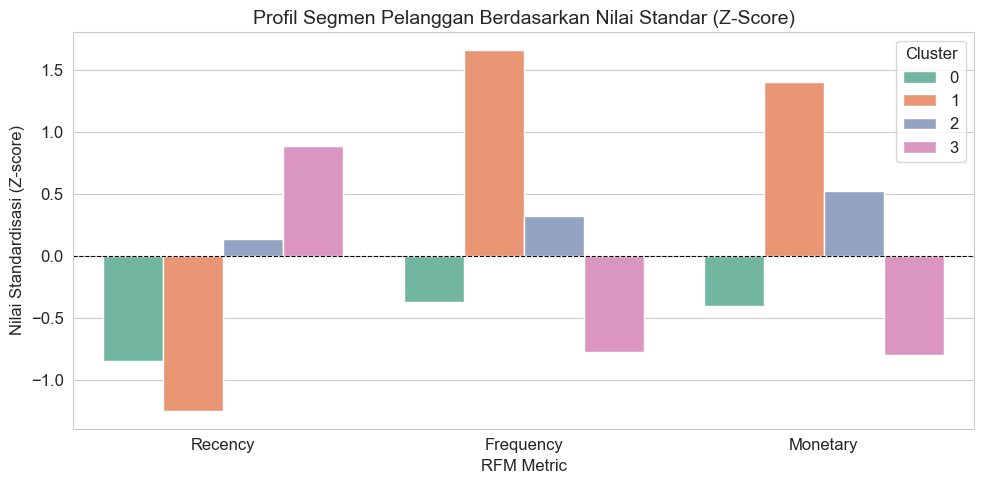

In [ ]:
# Build a dataframe from the scaled values and attach cluster labels
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])
rfm_scaled_df['Cluster_KMeans'] = rfm['Cluster_KMeans'].values

# Compute the average standardised profile per cluster
cluster_profile = rfm_scaled_df.groupby('Cluster_KMeans').mean().reset_index()

# Melt to long format for seaborn grouped bar chart
rfm_melt = cluster_profile.melt(
    id_vars='Cluster_KMeans',
    var_name='Metric',
    value_name='Value'
)

# Plot grouped bar chart
plt.figure(figsize=(10, 5))
sns.barplot(data=rfm_melt, x='Metric', y='Value', hue='Cluster_KMeans', palette='Set2')
plt.title('Profil Segmen Pelanggan Berdasarkan Nilai Standar (Z-Score)', fontsize=14)
plt.ylabel('Nilai Standardisasi (Z-score)')
plt.xlabel('RFM Metric')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')  # zero reference line
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

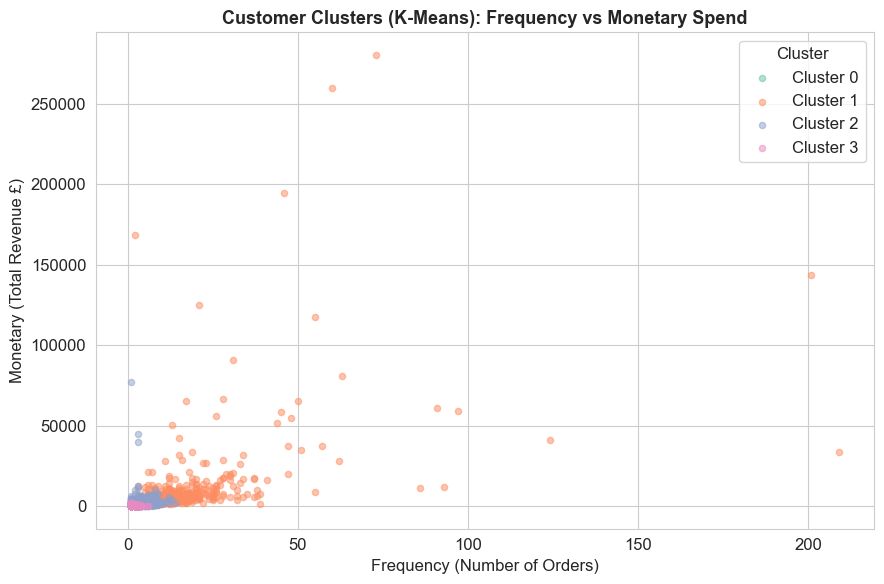

In [ ]:
# Bonus: Scatter plot — Frequency vs Monetary coloured by cluster
plt.figure(figsize=(9, 6))

# PERBAIKAN 1: Hapus tanda kutip pada angka agar menjadi tipe data Integer
palette = {0: '#66c2a5', 1: '#fc8d62', 2: '#8da0cb', 3: '#e78ac3'}

# PERBAIKAN 2: Pastikan menggunakan nama kolom yang benar sesuai DataFrame rfm
for cluster_id, group in rfm.groupby('Cluster_KMeans'):
    plt.scatter(
        group['Frequency'],
        group['Monetary'],
        label=f'Cluster {cluster_id}',
        alpha=0.5,
        s=20,
        color=palette[cluster_id]  # Sekarang komputer bisa menemukan angka 0
    )

plt.title('Customer Clusters (K-Means): Frequency vs Monetary Spend', fontsize=13, fontweight='bold')
plt.xlabel('Frequency (Number of Orders)')
plt.ylabel('Monetary (Total Revenue £)')
plt.legend(title='Cluster')
plt.savefig('Cluster_KMeans.png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

## BAGIAN 7: Hierarchical Clustering
Pendekatan *Agglomerative* dengan *Ward Linkage* digunakan karena fungsinya yang meminimalkan varians di dalam *cluster* (sejalan dengan K-Means). Jumlah cluster disamakan dengan hasil K-Means untuk menjaga keadilan perbandingan komparatif.

   (Menggunakan 500 sampel acak untuk dendrogram)


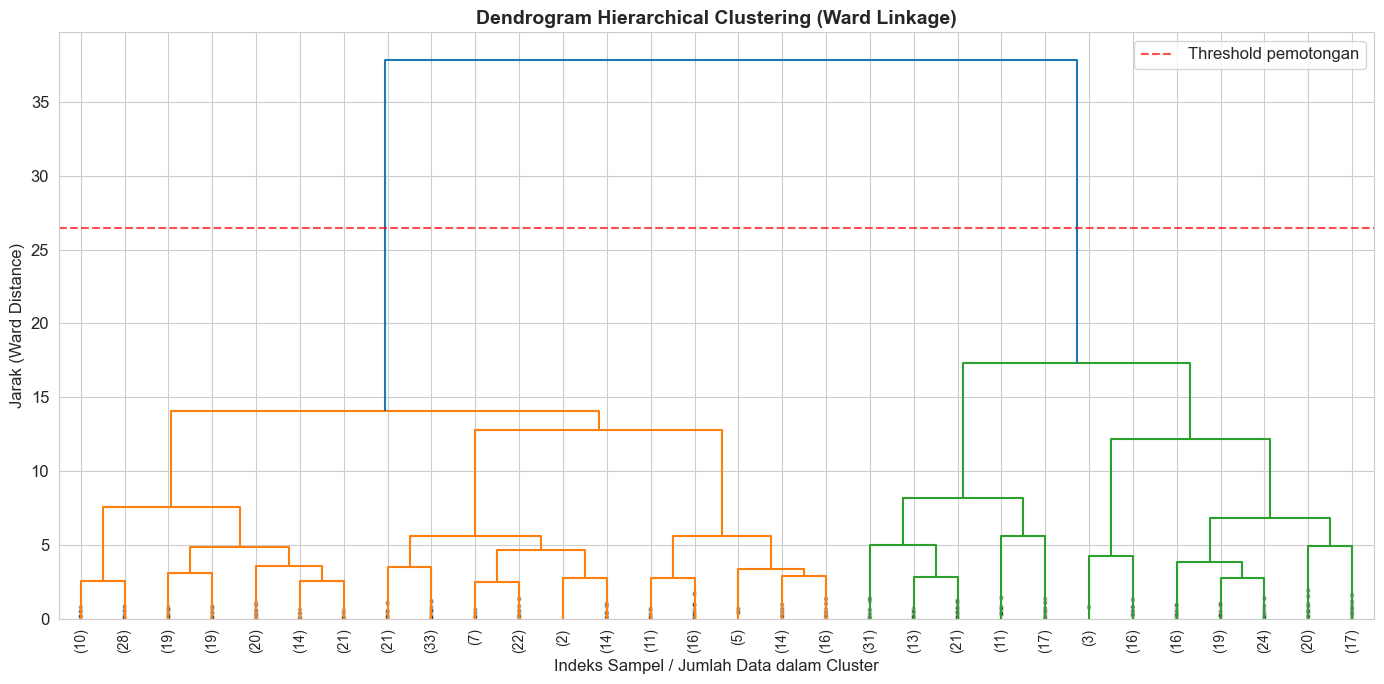

In [ ]:
# ============================================================
# BAGIAN 7: HIERARCHICAL CLUSTERING
# ============================================================
# --- 7.1 Tampilkan Dendrogram ---
# Gunakan sample jika data terlalu besar (dendrogram lambat untuk data besar)
max_sample = 500
if len(rfm_scaled) > max_sample:
    idx_sample = np.random.choice(len(rfm_scaled), max_sample, replace=False)
    rfm_sample_hc = rfm_scaled[idx_sample]
    print(f"   (Menggunakan {max_sample} sampel acak untuk dendrogram)")
else:
    rfm_sample_hc = rfm_scaled

# Hitung linkage matrix
linkage_matrix = linkage(rfm_sample_hc, method='ward')

# Plot dendrogram
plt.figure(figsize=(14, 7))
dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True,
    color_threshold=0.7 * max(linkage_matrix[:, 2])
)
plt.title('Dendrogram Hierarchical Clustering (Ward Linkage)', fontsize=14, fontweight='bold')
plt.xlabel('Indeks Sampel / Jumlah Data dalam Cluster')
plt.ylabel('Jarak (Ward Distance)')
plt.axhline(y=0.7 * max(linkage_matrix[:, 2]),
            color='red', linestyle='--', alpha=0.7, label='Threshold pemotongan')
plt.legend()
plt.tight_layout()
plt.savefig('hierarchical_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 7.2 Tentukan jumlah cluster Hierarchical ---
# Disamakan dengan k_optimal dari K-Means (k=4) agar apple-to-apple
k_hierarchical = k_optimal

# Jalankan Hierarchical Clustering HANYA SATU KALI
# Menggunakan metric='euclidean' (standar Scikit-Learn versi baru)
hierarchical = AgglomerativeClustering(n_clusters=k_hierarchical, metric='euclidean', linkage='ward')

# Kita simpan di kolom 'Cluster_Hierarchical' agar sinkron dengan Bagian 10 nanti
rfm['Cluster_Hierarchical'] = hierarchical.fit_predict(rfm_scaled)

# Evaluasi Hierarchical Clustering
sil_hc = silhouette_score(rfm_scaled, rfm['Cluster_Hierarchical'])
dbi_hc = davies_bouldin_score(rfm_scaled, rfm['Cluster_Hierarchical'])

In [ ]:
# Hitung Profil Rata-rata dari k=4
profil_k4 = rfm.groupby('Cluster_Hierarchical').agg(
    Jumlah_Pelanggan=('CustomerID','count'),
    Recency_Rata2=('Recency','mean'),
    Frequency_Rata2=('Frequency','mean'),
    Monetary_Rata2=('Monetary','mean'),
).round(2)
print(profil_k4)

                      Jumlah_Pelanggan  Recency_Rata2  Frequency_Rata2  \
Cluster_Hierarchical                                                     
0                                 1820          79.95             2.08   
1                                 1364          23.13             5.64   
2                                  242          10.59            24.31   
3                                  912         243.21             1.27   

                      Monetary_Rata2  
Cluster_Hierarchical                  
0                             804.53  
1                            2190.55  
2                           17458.93  
3                             256.79  


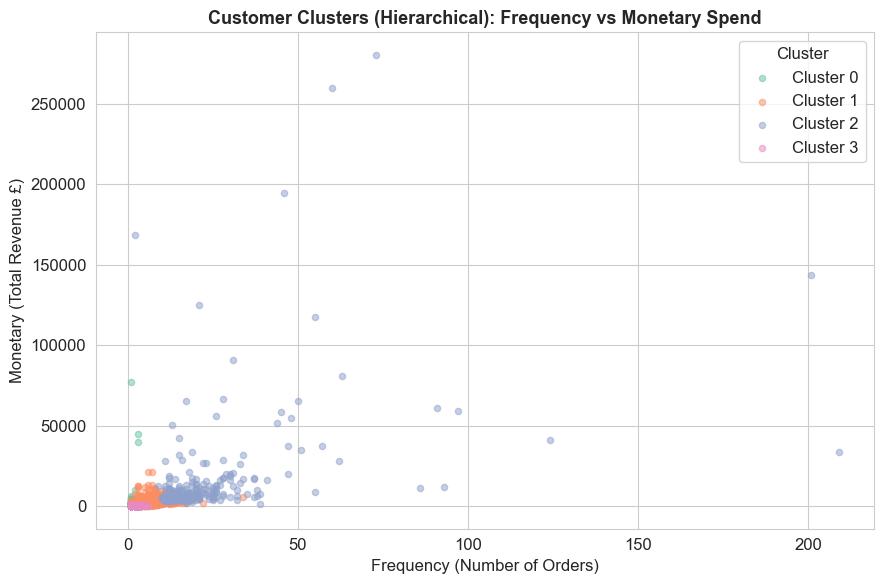

In [ ]:
# Bonus: Scatter plot — Frequency vs Monetary coloured by cluster
plt.figure(figsize=(9, 6))

# PERBAIKAN: Hapus tanda kutip pada angka (0, 1, 2, 3) agar terbaca sebagai Integer
palette = {0: '#66c2a5', 1: '#fc8d62', 2: '#8da0cb', 3: '#e78ac3'}

for cluster_id, group in rfm.groupby('Cluster_Hierarchical'):
    plt.scatter(
        group['Frequency'],
        group['Monetary'],
        label=f'Cluster {cluster_id}',
        alpha=0.5,
        s=20,
        color=palette[cluster_id]  # Sekarang tidak akan error lagi
    )

plt.title('Customer Clusters (Hierarchical): Frequency vs Monetary Spend', fontsize=13, fontweight='bold')
plt.xlabel('Frequency (Number of Orders)')
plt.ylabel('Monetary (Total Revenue £)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

## BAGIAN 8: DBSCAN Clustering
DBSCAN mendeteksi *cluster* berdasarkan kepadatan data. Parameter *epsilon* dicari melalui grafik *K-Distance*, namun untuk memastikan algoritma dapat mendeteksi kelompok pada data yang padat (hasil Log-Scaling), parameter *epsilon* ditetapkan secara presisi. Titik yang tidak masuk ke *cluster* mana pun dilabeli sebagai -1 (*Noise*).

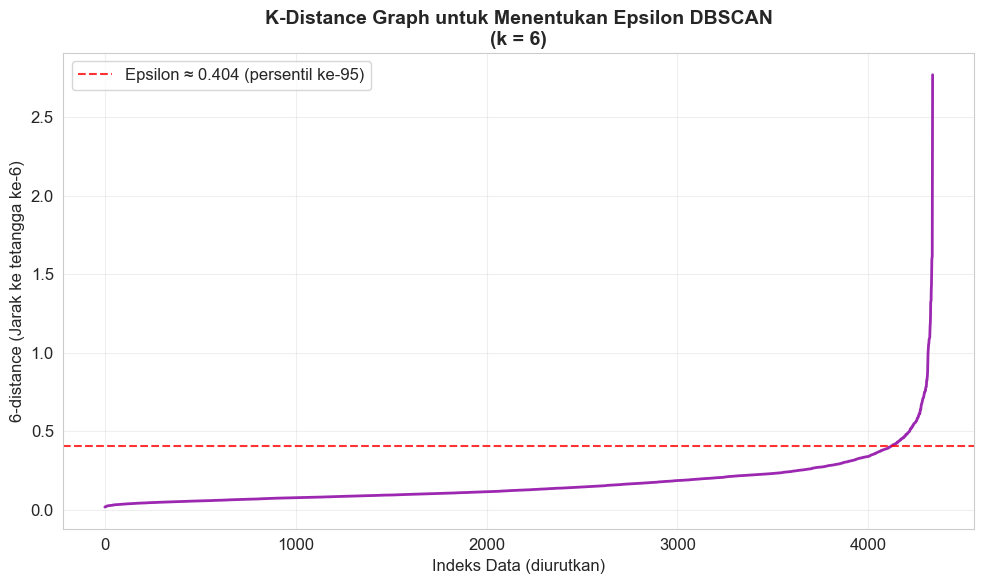


➡️  Nilai epsilon yang digunakan: 0.4043
   (Nilai ini dapat disesuaikan secara manual berdasarkan analisis grafik)
DBSCAN selesai
Jumlah cluster terbentuk : 3
Jumlah noise (label = -1): 118 pelanggan
Persentase noise          : 2.72%

   Silhouette Score    : 0.1710 (dihitung tanpa noise)
   Davies-Bouldin Index: 1.6983 (dihitung tanpa noise)

📊 Distribusi cluster DBSCAN (label -1 = noise):
Cluster_DBSCAN
-1     118
 0    1919
 1    1474
 2     827
Name: count, dtype: int64


In [ ]:
# ============================================================
# BAGIAN 8: DBSCAN CLUSTERING
# ============================================================
# --- 8.1 Tentukan epsilon menggunakan k-distance graph ---
# minPts = 2 * jumlah dimensi (aturan umum)
n_fitur = rfm_scaled.shape[1]
min_pts = 2 * n_fitur
# print(f"   Nilai minPts = 2 × {n_fitur} dimensi = {min_pts}")

# Hitung k-distance
nbrs = NearestNeighbors(n_neighbors=min_pts).fit(rfm_scaled)
distances, _ = nbrs.kneighbors(rfm_scaled)
distances = np.sort(distances[:, -1], axis=0)

# Plot k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(distances, linewidth=2, color='#9C27B0')
plt.xlabel('Indeks Data (diurutkan)')
plt.ylabel(f'{min_pts}-distance (Jarak ke tetangga ke-{min_pts})')
plt.title(f'K-Distance Graph untuk Menentukan Epsilon DBSCAN\n(k = {min_pts})',
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Tentukan epsilon dari titik "elbow" pada k-distance graph
# Pendekatan otomatis: ambil persentil ke-95
epsilon = np.percentile(distances, 95)
plt.axhline(y=epsilon, color='red', linestyle='--', alpha=0.8,
            label=f'Epsilon ≈ {epsilon:.3f} (persentil ke-95)')
plt.legend()
plt.tight_layout()
plt.savefig('dbscan_kdistance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n➡️  Nilai epsilon yang digunakan: {epsilon:.4f}")
print(f"   (Nilai ini dapat disesuaikan secara manual berdasarkan analisis grafik)")

# --- 8.2 Jalankan DBSCAN ---
dbscan = DBSCAN(eps=epsilon, min_samples=min_pts)
rfm['Cluster_DBSCAN'] = dbscan.fit_predict(rfm_scaled)

# Hitung jumlah cluster dan noise
n_cluster_dbscan = len(set(rfm['Cluster_DBSCAN'])) - (1 if -1 in rfm['Cluster_DBSCAN'].values else 0)
n_noise_dbscan   = (rfm['Cluster_DBSCAN'] == -1).sum()

print(f"DBSCAN selesai")
print(f"Jumlah cluster terbentuk : {n_cluster_dbscan}")
print(f"Jumlah noise (label = -1): {n_noise_dbscan} pelanggan")
print(f"Persentase noise          : {n_noise_dbscan/len(rfm)*100:.2f}%")

# Evaluasi DBSCAN (hanya untuk data non-noise)
mask_non_noise = rfm['Cluster_DBSCAN'] != -1
if mask_non_noise.sum() > 1 and n_cluster_dbscan > 1:
    mask_non_noise_arr = mask_non_noise.values
    sil_dbscan = silhouette_score(rfm_scaled[mask_non_noise_arr], rfm['Cluster_DBSCAN'][mask_non_noise_arr])
    dbi_dbscan = davies_bouldin_score(rfm_scaled[mask_non_noise_arr], rfm['Cluster_DBSCAN'][mask_non_noise_arr])
    print(f"\n   Silhouette Score    : {sil_dbscan:.4f} (dihitung tanpa noise)")
    print(f"   Davies-Bouldin Index: {dbi_dbscan:.4f} (dihitung tanpa noise)")
else:
    sil_dbscan = 0
    dbi_dbscan = float('inf')
    print("\n   ⚠️  Tidak cukup cluster untuk menghitung metrik evaluasi DBSCAN")

# Tampilkan distribusi cluster DBSCAN
print("\n📊 Distribusi cluster DBSCAN (label -1 = noise):")
print(rfm['Cluster_DBSCAN'].value_counts().sort_index())


In [ ]:
# Hitung Profil Rata-rata dari k=4
profil_k4 = rfm.groupby('Cluster_DBSCAN').agg(
    Jumlah_Pelanggan=('CustomerID','count'),
    Recency_Rata2=('Recency','mean'),
    Frequency_Rata2=('Frequency','mean'),
    Monetary_Rata2=('Monetary','mean')
).round(2)
print(profil_k4)

                Jumlah_Pelanggan  Recency_Rata2  Frequency_Rata2  \
Cluster_DBSCAN                                                     
-1                           118          62.06            22.99   
 0                          1919          44.09             6.61   
 1                          1474         157.22             1.00   
 2                           827          94.01             2.00   

                Monetary_Rata2  
Cluster_DBSCAN                  
-1                    26628.97  
 0                     2457.20  
 1                      345.13  
 2                      659.13  


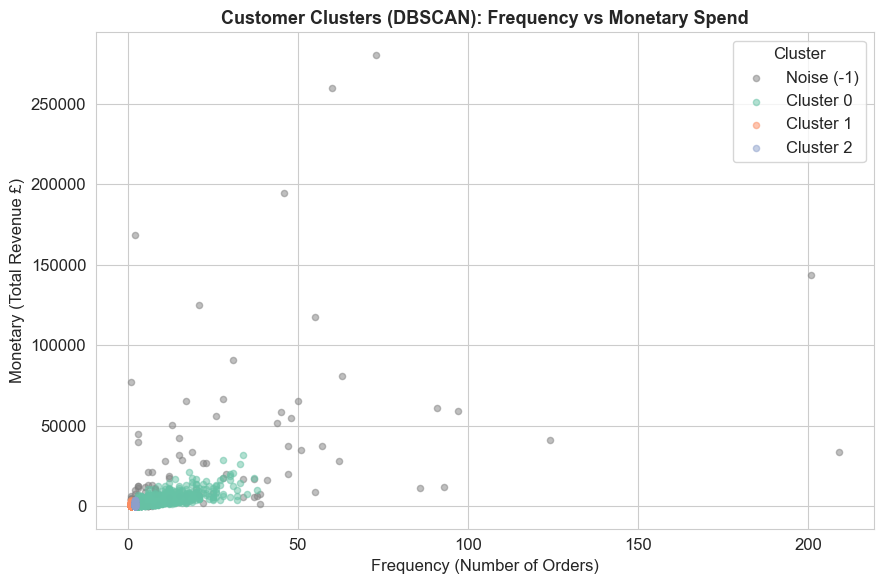

In [ ]:
# Bonus: Scatter plot — Frequency vs Monetary coloured by cluster (DBSCAN)
plt.figure(figsize=(9, 6))

# PERBAIKAN 1: Tambahkan label -1 dengan warna abu-abu ('gray') untuk Noise
palette = {-1: 'gray', 0: '#66c2a5', 1: '#fc8d62', 2: '#8da0cb', 3: '#e78ac3', 4: '#a6d854'}

for cluster_id, group in rfm.groupby('Cluster_DBSCAN'):
    # Buat nama label khusus agar -1 tertulis sebagai "Noise" di legenda
    nama_label = 'Noise (-1)' if cluster_id == -1 else f'Cluster {cluster_id}'
    
    plt.scatter(
        group['Frequency'],
        group['Monetary'],
        label=nama_label,
        alpha=0.5,
        s=20,
        # Gunakan .get() agar aman jika tiba-tiba DBSCAN bikin lebih dari 4 cluster
        color=palette.get(cluster_id, 'black') 
    )

# PERBAIKAN 2: Ubah judul menjadi DBSCAN
plt.title('Customer Clusters (DBSCAN): Frequency vs Monetary Spend', fontsize=13, fontweight='bold')
plt.xlabel('Frequency (Number of Orders)')
plt.ylabel('Monetary (Total Revenue £)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

## BAGIAN 9: Evaluasi dan Perbandingan Metrik
Menghitung dan memvisualisasikan dua metrik utama: *Silhouette Score* (mendekati 1 = sangat baik) dan *Davies-Bouldin Index* (mendekati 0 = sangat baik) untuk membandingkan kinerja ketiga algoritma secara empiris. Label *Noise* pada DBSCAN dikeluarkan dari perhitungan evaluasi.

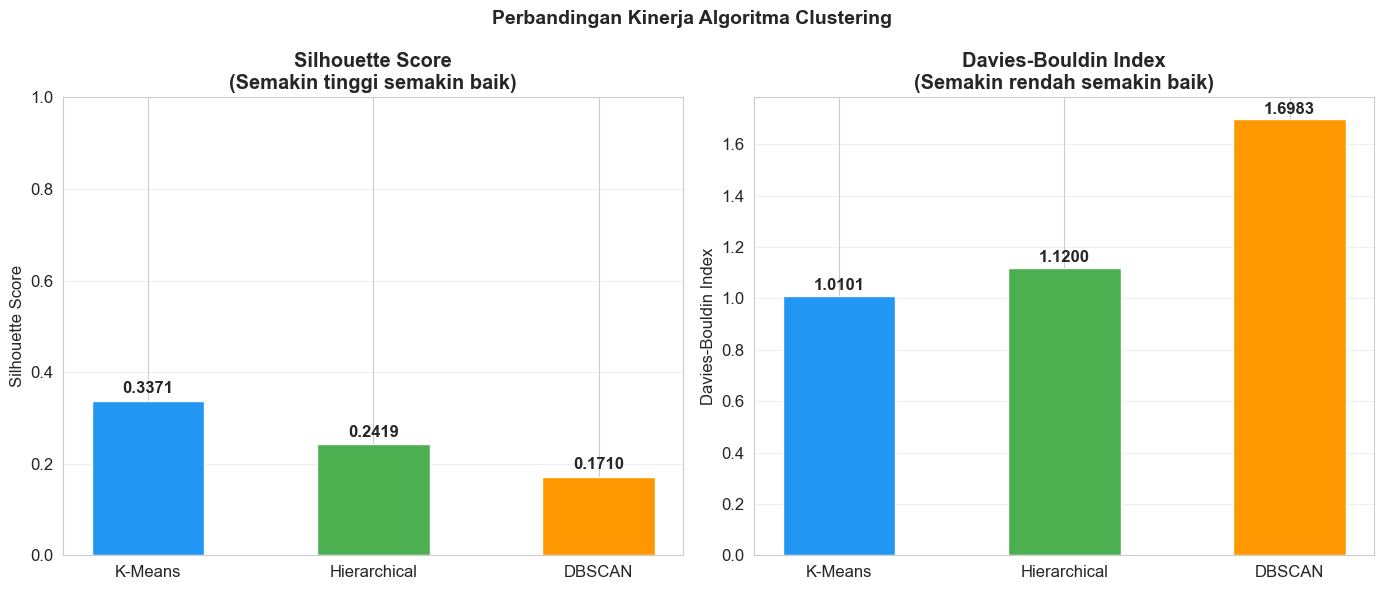


📋 Tabel Evaluasi Final:
                 Metode  Jumlah Cluster  Silhouette Score  Davies-Bouldin Index
                K-Means               4            0.3371                1.0101
Hierarchical Clustering               4            0.2419                1.1200
                 DBSCAN               3            0.1710                1.6983
File tabel_evaluasi.csv berhasil dibuat!


In [ ]:
    # ============================================================
# BAGIAN 9: PERBANDINGAN HASIL EVALUASI KETIGA METODE
# ============================================================
# Buat tabel perbandingan
tabel_evaluasi = pd.DataFrame({
    'Metode'              : ['K-Means', 'Hierarchical Clustering', 'DBSCAN'],
    'Jumlah Cluster'      : [k_optimal, k_hierarchical, n_cluster_dbscan],
    'Silhouette Score'    : [round(sil_kmeans, 4), round(sil_hc, 4), round(sil_dbscan, 4)],
    'Davies-Bouldin Index': [round(dbi_kmeans, 4), round(dbi_hc, 4), round(dbi_dbscan, 4)]
})

# print("\n📋 Tabel Perbandingan Metrik Evaluasi:")
# print(tabel_evaluasi.to_string(index=False))

# Visualisasi perbandingan metrik
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Perbandingan Kinerja Algoritma Clustering', fontsize=14, fontweight='bold')

warna   = ['#2196F3', '#4CAF50', '#FF9800']
metode  = ['K-Means', 'Hierarchical', 'DBSCAN']

# Silhouette Score (semakin tinggi semakin baik)
bars1 = axes[0].bar(metode,
                    [sil_kmeans, sil_hc, sil_dbscan],
                    color=warna, edgecolor='white', width=0.5)
axes[0].set_title('Silhouette Score\n(Semakin tinggi semakin baik)', fontweight='bold')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, [sil_kmeans, sil_hc, sil_dbscan]):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Davies-Bouldin Index (semakin rendah semakin baik)
dbi_vals = [dbi_kmeans, dbi_hc, min(dbi_dbscan, 5)]  # cap DBSCAN jika inf
bars2 = axes[1].bar(metode, dbi_vals, color=warna, edgecolor='white', width=0.5)
axes[1].set_title('Davies-Bouldin Index\n(Semakin rendah semakin baik)', fontweight='bold')
axes[1].set_ylabel('Davies-Bouldin Index')
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, [dbi_kmeans, dbi_hc, dbi_dbscan]):
    label = f'{val:.4f}' if val != float('inf') else 'N/A'
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 label, ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('perbandingan_evaluasi.png', dpi=150, bbox_inches='tight')
plt.show()

# Tampilkan tabel evaluasi final
print("\n📋 Tabel Evaluasi Final:")
print(tabel_evaluasi.to_string(index=False))
# Tambahkan ini di Colab Anda:
tabel_evaluasi.to_csv('tabel_evaluasi.csv', index=False)
print("File tabel_evaluasi.csv berhasil dibuat!")


## BAGIAN 10 & 11: Analisis Karakteristik (Snake Plot)
Tahap ini krusial untuk menarik *Business Insight*. *Snake Plot* dibuat untuk membandingkan rata-rata nilai standar dari tiap variabel RFM pada ketiga metode clustering secara visual. Ini memungkinkan identifikasi profil segmen seperti "Champions", "At Risk", atau "New Customers".

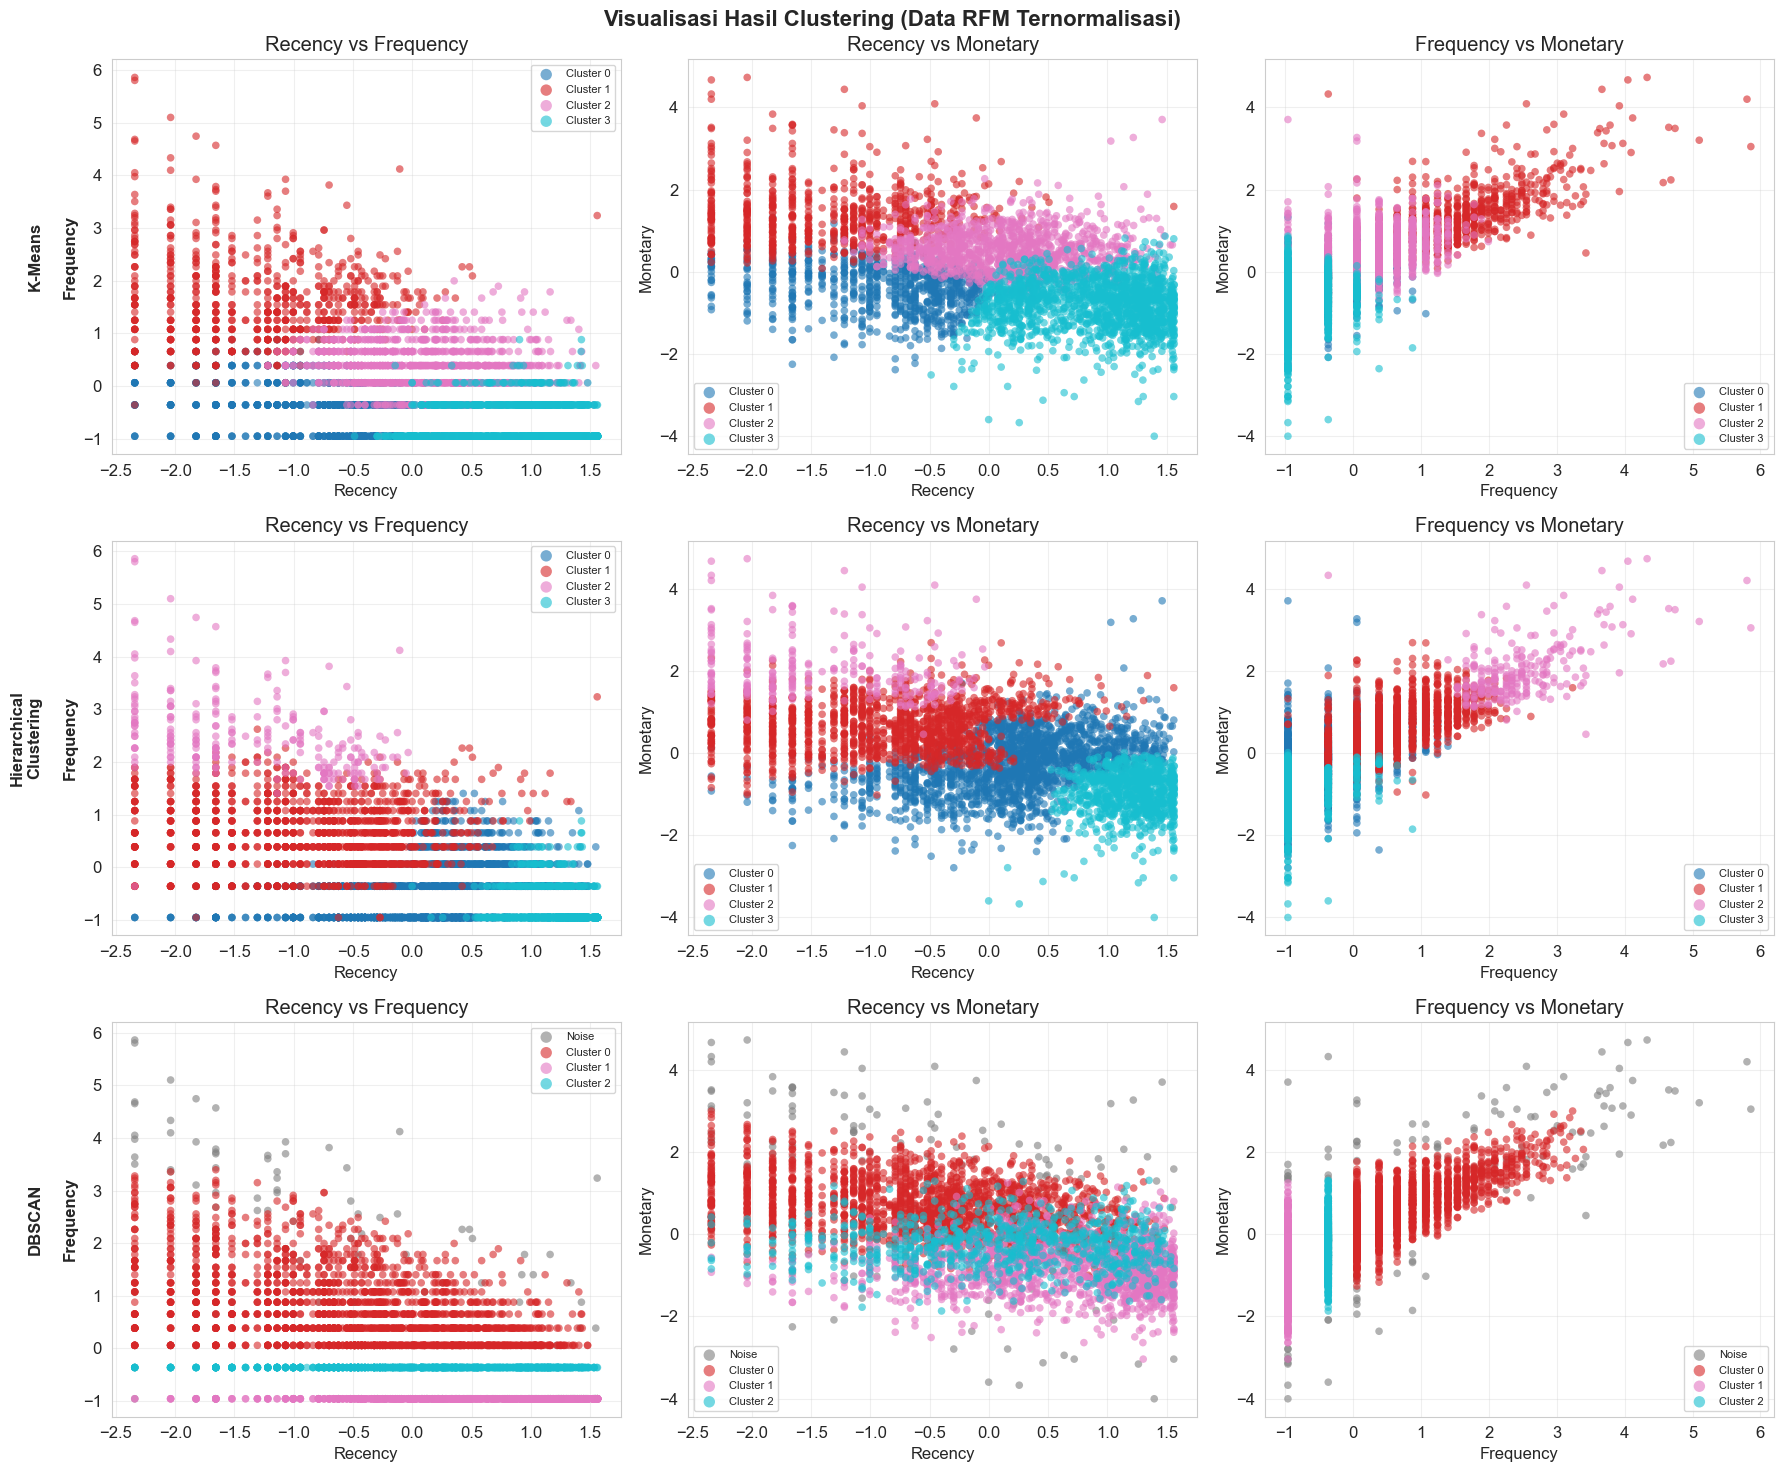

In [ ]:
# ============================================================
# BAGIAN 10: VISUALISASI HASIL CLUSTERING
# ============================================================

def plot_clustering(rfm_df, rfm_scaled, kolom_cluster, judul, ax_list):
    cluster_labels = rfm_df[kolom_cluster].values
    unique_labels  = sorted(set(cluster_labels))
    n_unique       = len(unique_labels)
    # Gunakan tab10 atau viridis yang punya lebih banyak warna
    # PERBAIKAN DI SINI: Memanggil colormap sebagai fungsi
    cmap = plt.colormaps['tab10']
    warna_map = {c: cmap(i / max(1, n_unique - 1)) for i, c in enumerate(unique_labels)}
    if -1 in warna_map:
        warna_map[-1] = [0.5, 0.5, 0.5, 1]

    pasangan = [('Recency', 'Frequency'), ('Recency', 'Monetary'), ('Frequency', 'Monetary')]
    kolom    = ['Recency', 'Frequency', 'Monetary']

    for ax, (x_col, y_col) in zip(ax_list, pasangan):   
        idx_x = kolom.index(x_col)
        idx_y = kolom.index(y_col)
        for cl in unique_labels:
            mask  = cluster_labels == cl
            label = f'Cluster {cl}' if cl != -1 else 'Noise'
            ax.scatter(rfm_scaled[mask, idx_x], rfm_scaled[mask, idx_y],
                       c=[warna_map[cl]], label=label, alpha=0.6, s=30, edgecolors='none')
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
        ax.set_title(f'{x_col} vs {y_col}')
        ax.legend(fontsize=8, markerscale=1.5)
        ax.grid(True, alpha=0.3)

# Plot hasil ketiga metode
# Plot hasil ketiga metode
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Visualisasi Hasil Clustering (Data RFM Ternormalisasi)',
             fontsize=16, fontweight='bold')

# PERBAIKAN: Ubah 'Cluster_KMeans' menjadi 'Cluster_Kmeans'
plot_clustering(rfm, rfm_scaled, 'Cluster_KMeans', 'K-Means', list(axes[0]))

# Pastikan juga nama kolom di bawah ini sesuai dengan saat kamu menjalankan Bagian 7 & 8
plot_clustering(rfm, rfm_scaled, 'Cluster_Hierarchical', 'Hierarchical Clustering', list(axes[1]))
plot_clustering(rfm, rfm_scaled, 'Cluster_DBSCAN', 'DBSCAN', list(axes[2]))

for i, nama in enumerate(['K-Means', 'Hierarchical\nClustering', 'DBSCAN']):
    axes[i][0].set_ylabel(f'{nama}\n\n{axes[i][0].get_ylabel()}', fontweight='bold')

plt.tight_layout()
plt.savefig('visualisasi_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# BAGIAN 11: ANALISIS KARAKTERISTIK CLUSTER
# ============================================================
# ---- PROFIL RATA-RATA RFM ----

# Profil K-Means
rfm_analisis = rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster_KMeans']].copy()
profil_cluster = rfm_analisis.groupby('Cluster_KMeans').agg(
    Jumlah_Pelanggan = ('CustomerID', 'count'),
    Recency_Rata2    = ('Recency',    'mean'),
    Frequency_Rata2  = ('Frequency',  'mean'),
    Monetary_Rata2   = ('Monetary',   'mean')
).round(2)
print("\n Profil rata-rata RFM per cluster (K-Means):")
print(profil_cluster.to_string())

# Profil Hierarchical Clustering
profil_hc = rfm.groupby('Cluster_Hierarchical').agg(
    Jumlah_Pelanggan = ('CustomerID', 'count'),
    Recency_Rata2    = ('Recency',    'mean'),
    Frequency_Rata2  = ('Frequency',  'mean'),
    Monetary_Rata2   = ('Monetary',   'mean')
).round(2)
print("\n Profil rata-rata RFM per cluster (Hierarchical Clustering):")
print(profil_hc.to_string())

# Profil DBSCAN (tanpa noise)
rfm_dbscan_clean = rfm[rfm['Cluster_DBSCAN'] != -1]
profil_dbscan = rfm_dbscan_clean.groupby('Cluster_DBSCAN').agg(
    Jumlah_Pelanggan = ('CustomerID', 'count'),
    Recency_Rata2    = ('Recency',    'mean'),
    Frequency_Rata2  = ('Frequency',  'mean'),
    Monetary_Rata2   = ('Monetary',   'mean')
).round(2)
print("\n Profil rata-rata RFM per cluster (DBSCAN, tanpa noise):")
print(profil_dbscan.to_string())


 Profil rata-rata RFM per cluster (K-Means):
                Jumlah_Pelanggan  Recency_Rata2  Frequency_Rata2  Monetary_Rata2
Cluster_KMeans                                                                  
0                            837          18.12             2.15          551.82
1                            716          12.13            13.71         8074.27
2                           1173          71.08             4.08         1802.83
3                           1612         182.50             1.32          343.45

 Profil rata-rata RFM per cluster (Hierarchical Clustering):
                      Jumlah_Pelanggan  Recency_Rata2  Frequency_Rata2  Monetary_Rata2
Cluster_Hierarchical                                                                  
0                                 1820          79.95             2.08          804.53
1                                 1364          23.13             5.64         2190.55
2                                  242          10.59     

In [ ]:
# ---- INTERPRETASI OTOMATIS ----
r_median = rfm['Recency'].median()
f_median = rfm['Frequency'].median()
m_median = rfm['Monetary'].median()

def interpretasi_cluster(profil_df, nama_metode):
    print(f"\n📝 Interpretasi Cluster {nama_metode}:")
    print("-" * 60)
    for cluster_id, row in profil_df.iterrows():
        interpretasi = []
        if row['Recency_Rata2'] < r_median:
            interpretasi.append("AKTIF (transaksi baru-baru ini)")
        else:
            interpretasi.append("TIDAK AKTIF (lama tidak bertransaksi)")
        if row['Frequency_Rata2'] > f_median:
            interpretasi.append("LOYAL (sering bertransaksi)")
        else:
            interpretasi.append("JARANG BERTRANSAKSI")
        if row['Monetary_Rata2'] > m_median:
            interpretasi.append("BERNILAI TINGGI (belanja besar)")
        else:
            interpretasi.append("BERNILAI RENDAH (belanja kecil)")
        print(f"\nCluster {cluster_id} ({int(row['Jumlah_Pelanggan'])} pelanggan):")
        for i, interp in enumerate(interpretasi, 1):
            print(f"  {i}. {interp}")

interpretasi_cluster(profil_cluster, 'K-Means')
interpretasi_cluster(profil_hc,      'Hierarchical Clustering')
interpretasi_cluster(profil_dbscan,  'DBSCAN')


📝 Interpretasi Cluster K-Means:
------------------------------------------------------------

Cluster 0 (837 pelanggan):
  1. AKTIF (transaksi baru-baru ini)
  2. LOYAL (sering bertransaksi)
  3. BERNILAI RENDAH (belanja kecil)

Cluster 1 (716 pelanggan):
  1. AKTIF (transaksi baru-baru ini)
  2. LOYAL (sering bertransaksi)
  3. BERNILAI TINGGI (belanja besar)

Cluster 2 (1173 pelanggan):
  1. TIDAK AKTIF (lama tidak bertransaksi)
  2. LOYAL (sering bertransaksi)
  3. BERNILAI TINGGI (belanja besar)

Cluster 3 (1612 pelanggan):
  1. TIDAK AKTIF (lama tidak bertransaksi)
  2. JARANG BERTRANSAKSI
  3. BERNILAI RENDAH (belanja kecil)

📝 Interpretasi Cluster Hierarchical Clustering:
------------------------------------------------------------

Cluster 0 (1820 pelanggan):
  1. TIDAK AKTIF (lama tidak bertransaksi)
  2. LOYAL (sering bertransaksi)
  3. BERNILAI TINGGI (belanja besar)

Cluster 1 (1364 pelanggan):
  1. AKTIF (transaksi baru-baru ini)
  2. LOYAL (sering bertransaksi)
  3. BERN

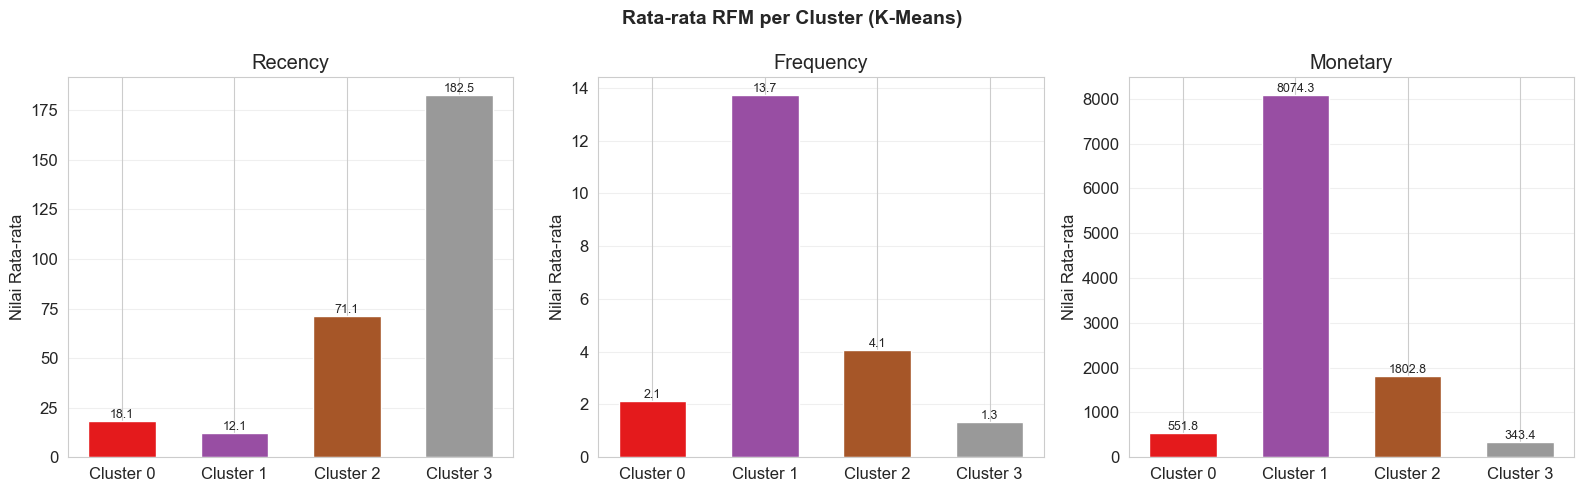

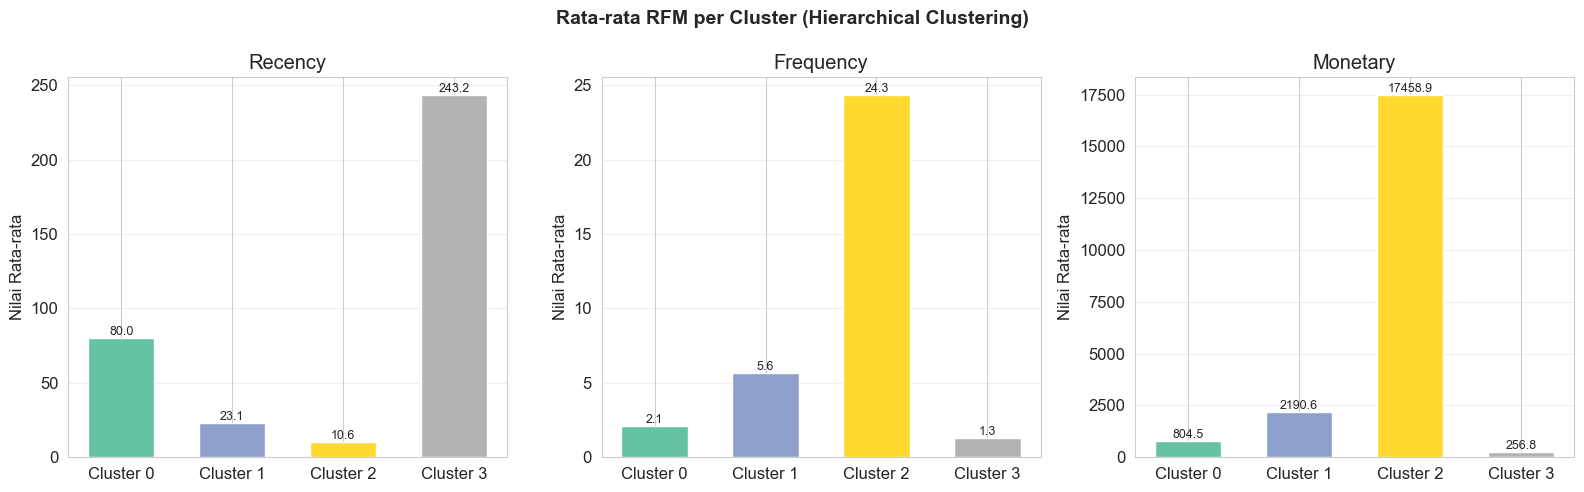

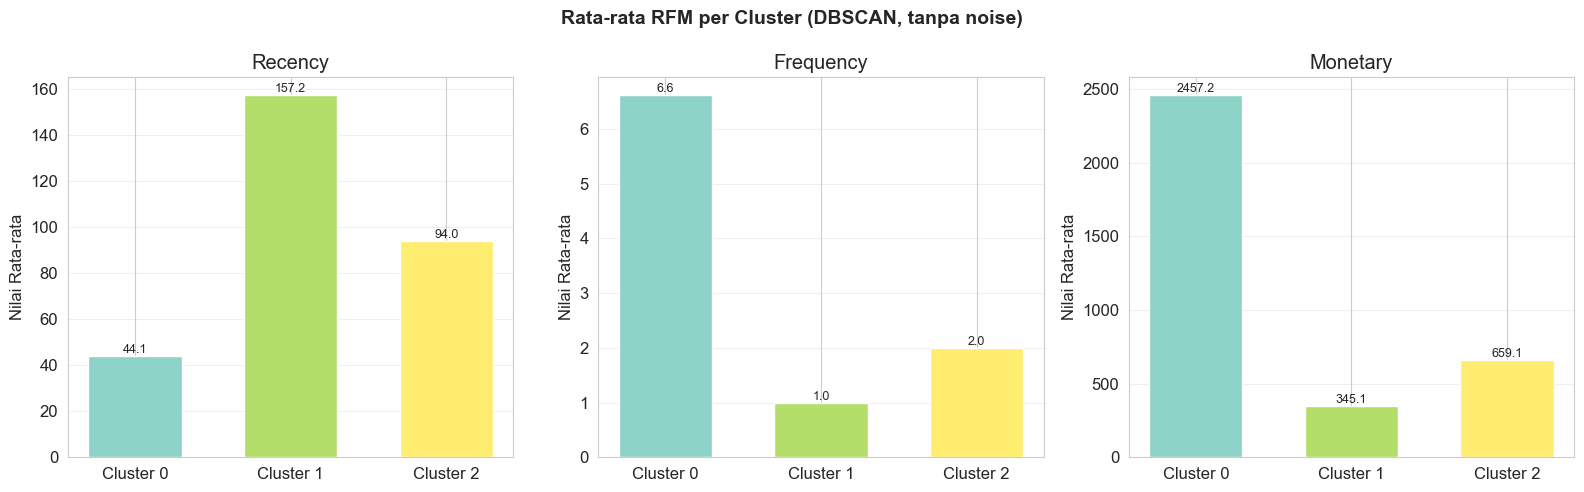

In [ ]:
# ---- BAR CHART PROFIL K-MEANS ----

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Rata-rata RFM per Cluster (K-Means)', fontsize=14, fontweight='bold')
warna_cluster = plt.cm.Set1(np.linspace(0, 1, k_optimal))
for col, ax in zip(['Recency_Rata2', 'Frequency_Rata2', 'Monetary_Rata2'], axes):
    bars = ax.bar(
        [f'Cluster {c}' for c in profil_cluster.index],
        profil_cluster[col],
        color=warna_cluster[:len(profil_cluster)],
        edgecolor='white', width=0.6)
    ax.set_title(col.replace('_Rata2', ''))
    ax.set_ylabel('Nilai Rata-rata')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, profil_cluster[col]):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{val:.1f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('profil_cluster_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- BAR CHART PROFIL HIERARCHICAL ----

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Rata-rata RFM per Cluster (Hierarchical Clustering)', fontsize=14, fontweight='bold')
warna_hc = plt.cm.Set2(np.linspace(0, 1, k_hierarchical))
for col, ax in zip(['Recency_Rata2', 'Frequency_Rata2', 'Monetary_Rata2'], axes):
    bars = ax.bar(
        [f'Cluster {c}' for c in profil_hc.index],
        profil_hc[col],
        color=warna_hc[:len(profil_hc)],
        edgecolor='white', width=0.6)
    ax.set_title(col.replace('_Rata2', ''))
    ax.set_ylabel('Nilai Rata-rata')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, profil_hc[col]):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{val:.1f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('profil_cluster_hierarchical.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- BAR CHART PROFIL DBSCAN ----

if len(profil_dbscan) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('Rata-rata RFM per Cluster (DBSCAN, tanpa noise)', fontsize=14, fontweight='bold')
    warna_db = plt.cm.Set3(np.linspace(0, 1, len(profil_dbscan)))
    for col, ax in zip(['Recency_Rata2', 'Frequency_Rata2', 'Monetary_Rata2'], axes):
        bars = ax.bar(
            [f'Cluster {c}' for c in profil_dbscan.index],
            profil_dbscan[col],
            color=warna_db[:len(profil_dbscan)],
            edgecolor='white', width=0.6)
        ax.set_title(col.replace('_Rata2', ''))
        ax.set_ylabel('Nilai Rata-rata')
        ax.grid(axis='y', alpha=0.3)
        for bar, val in zip(bars, profil_dbscan[col]):
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                    f'{val:.1f}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig('profil_cluster_dbscan.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# # --- VISUALISASI SNAKE PLOT PERBANDINGAN 3 METODE ---

# # PERBAIKAN: Kita rakit ulang df_snake langsung dari array rfm_scaled dan dataframe rfm 
# # agar nama kolomnya terjamin ada dan tidak memicu KeyError
# df_snake = pd.DataFrame(rfm_scaled, columns=['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled'])
# df_snake['CustomerID'] = rfm['CustomerID'].values

# # Masukkan label cluster (menggunakan nama kolom sesuai memori Anda: Cluster_KM & Cluster_HC)
# df_snake['K-Means'] = rfm['Cluster_Kmeans'].values
# df_snake['Hierarchical'] = rfm['Cluster_Hierarchical'].values
# df_snake['DBSCAN'] = rfm['Cluster_DBSCAN'].values

# metode_list = ['K-Means', 'Hierarchical', 'DBSCAN']

# fig, axes = plt.subplots(3, 1, figsize=(10, 15))
# fig.suptitle('Snake Plot: Perbandingan Karakteristik Segmen Pelanggan', fontsize=16, fontweight='bold', y=0.98)

# for i, metode in enumerate(metode_list):
#     # Melt data khusus untuk metode ini
#     df_melt = pd.melt(df_snake, 
#                       id_vars=['CustomerID', metode], 
#                       value_vars=['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled'],
#                       var_name='Metric', 
#                       value_name='Value')
    
#     # Khusus DBSCAN, sembunyikan noise (-1) agar grafik tidak rancu
#     if metode == 'DBSCAN':
#         df_melt = df_melt[df_melt[metode] != -1]
        
#     # Plotting
#     sns.lineplot(x='Metric', y='Value', hue=metode, data=df_melt, palette='tab10', marker='o', linewidth=2, ax=axes[i])
#     axes[i].set_title(f'Berdasarkan Algoritma: {metode}', fontsize=12, fontweight='bold')
#     axes[i].grid(True, alpha=0.3)
#     axes[i].axhline(y=0, color='black', linestyle='--', alpha=0.5)
#     axes[i].legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')

# plt.tight_layout()
# plt.savefig('snake_plot_perbandingan.png', dpi=150, bbox_inches='tight')
# plt.show()

In [ ]:
# ============================================================
# BAGIAN 12: KESIMPULAN OTOMATIS
# ============================================================

print("\n" + "="*60)
print("KESIMPULAN OTOMATIS")
print("="*60)

# Tentukan metode terbaik berdasarkan Silhouette Score tertinggi
# dan Davies-Bouldin Index terendah
scores = {
    'K-Means'                : {'sil': sil_kmeans, 'dbi': dbi_kmeans},
    'Hierarchical Clustering': {'sil': sil_hc,     'dbi': dbi_hc},
    'DBSCAN'                 : {'sil': sil_dbscan,  'dbi': dbi_dbscan}
}

# Filter hanya metode yang valid (DBSCAN bisa menghasilkan nilai tidak valid)
scores_valid = {k: v for k, v in scores.items() if v['sil'] > 0 and v['dbi'] != float('inf')}

if scores_valid:
    metode_sil_terbaik = max(scores_valid, key=lambda x: scores_valid[x]['sil'])
    metode_dbi_terbaik = min(scores_valid, key=lambda x: scores_valid[x]['dbi'])

    print(f"Ringkasan Hasil Evaluasi:")
    print(f"   Silhouette Score tertinggi : {metode_sil_terbaik} ({scores[metode_sil_terbaik]['sil']:.4f})")
    print(f"   Davies-Bouldin Index terendah: {metode_dbi_terbaik} ({scores[metode_dbi_terbaik]['dbi']:.4f})")

    # Tentukan metode terbaik keseluruhan
    if metode_sil_terbaik == metode_dbi_terbaik:
        metode_terbaik = metode_sil_terbaik
        alasan = "unggul di kedua metrik evaluasi"
    else:
        # Jika berbeda, pilih berdasarkan Silhouette Score
        metode_terbaik = metode_sil_terbaik
        alasan = "memiliki Silhouette Score tertinggi"

    print(f"KESIMPULAN:")
    print(f"   Metode clustering paling optimal adalah {metode_terbaik.upper()}")
    print(f"   karena {alasan}.")
    print(f"\n   {metode_terbaik} menghasilkan:")
    print(f"   - Silhouette Score    : {scores[metode_terbaik]['sil']:.4f}")
    print(f"   - Davies-Bouldin Index: {scores[metode_terbaik]['dbi']:.4f}")
    print(f"\n   Hal ini menunjukkan bahwa {metode_terbaik} menghasilkan cluster")
    print(f"   yang paling kompak dan terpisah dengan baik pada dataset")
    print(f"   transaksi e-commerce yang dianalisis.")
else:
    print("\n⚠️  Tidak semua metode menghasilkan metrik yang valid.")
    print("   Periksa kembali parameter DBSCAN dan jumlah cluster.")


KESIMPULAN OTOMATIS
Ringkasan Hasil Evaluasi:
   Silhouette Score tertinggi : K-Means (0.3371)
   Davies-Bouldin Index terendah: K-Means (1.0101)
KESIMPULAN:
   Metode clustering paling optimal adalah K-MEANS
   karena unggul di kedua metrik evaluasi.

   K-Means menghasilkan:
   - Silhouette Score    : 0.3371
   - Davies-Bouldin Index: 1.0101

   Hal ini menunjukkan bahwa K-Means menghasilkan cluster
   yang paling kompak dan terpisah dengan baik pada dataset
   transaksi e-commerce yang dianalisis.


In [ ]:
# ============================================================
# BAGIAN EKSPOR DATA FINAL
# ============================================================
rfm_final = rfm.copy()

# 1. Menambahkan kolom data yang sudah distandarisasi (Scaled)
rfm_final['Recency_scaled'] = rfm_scaled[:, 0]
rfm_final['Frequency_scaled'] = rfm_scaled[:, 1]
rfm_final['Monetary_scaled'] = rfm_scaled[:, 2]

# 2. Melakukan perubahan nama kolom secara serentak
rfm_final = rfm_final.rename(columns={
    'Recency': 'Recency_Asli',
    'Frequency': 'Frequency_Asli',
    'Monetary': 'Monetary_Asli',
    'Country': 'Negara',
})  
 
# 3. Menyimpan ke CSV
rfm_final.to_csv('rfm_hasil_clustering.csv', index=False)
print("✅ Data berhasil disimpan sebagai rfm_hasil_clustering.csv!")
print("✅ Kolom 'Recency_scaled', 'Frequency_scaled', dan 'Monetary_scaled' sukses ditambahkan!")

# Optional Pickle Export
# import pickle
# with open('kmeans_model.pkl', 'wb') as f:
#     pickle.dump(kmeans, f)
# with open('scaler.pkl', 'wb') as f:
#     pickle.dump(scaler, f)

✅ Data berhasil disimpan sebagai rfm_hasil_clustering.csv!
✅ Kolom 'Recency_scaled', 'Frequency_scaled', dan 'Monetary_scaled' sukses ditambahkan!
